[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/06_end_to_end_projects/text_classification/text_classification.ipynb)


# 02 . Text Classification with a Transformer Encoder (from scratch)

## Concept — Transformer text classifier (revision notes)

**What it is**
- Turn a sentence into token ids, embed them, let self-attention mix information
  between positions, and read the class off a special `<cls>` position.
- Everything (tokenizer, attention, blocks, training loop) is written by hand here so
  no step is a black box.

**Why it matters**
- Almost every modern NLP model (BERT-style classifiers, rerankers, embedding models) is
  this recipe at larger scale. Understanding padding masks and the `<cls>` readout
  prevents the most common silent bugs.
- Our synthetic data has *negation* ("not good" is negative), a pattern that a bag-of-words
  model provably cannot represent but attention can.

**When to use**
- Short/medium text with labels, where word order or interactions matter.
- With very little data or only keyword signals, a linear model on counts is often enough -
  always keep that baseline.

**Math & intuition**
- Attention: `softmax(Q K^T / sqrt(d_k)) V`. Each token builds its new vector as a weighted average of
  value vectors of the tokens it looks at. Padding positions get score `-inf` so their weight is exactly 0.
- Pre-LN block: `x = x + Attn(LN(x))`, `x = x + MLP(LN(x))`. The residual path keeps gradients healthy.
- Label here = `positive_adjective XOR negated`. XOR is not linearly separable in count features,
  so a bag-of-words linear model is capped near the base rate of the more frequent combo.

### 1. Setup and imports

**What this cell does (plain language):** makes the project folder importable, imports the helper modules, and seeds the RNG.

In [1]:
import os, sys, subprocess
# The notebook imports a small tested module that lives next to it.
# On Colab that folder is not there yet, so fetch the repo once and move into the project directory.
PROJECT = "06_end_to_end_projects/text_classification"
if not os.path.exists("data.py"):
    if not os.path.exists("PyTorch-Mastery"):
        subprocess.run(["git", "clone", "-q", "https://github.com/himanshu231204/PyTorch-Mastery"], check=False)
    if os.path.isdir("PyTorch-Mastery/" + PROJECT):
        os.chdir("PyTorch-Mastery/" + PROJECT)
sys.path.insert(0, os.getcwd())

import torch, torch.nn as nn
import matplotlib.pyplot as plt
from data import make_corpus, Tokenizer
from model import TransformerClassifier, SelfAttention
from train import fit, evaluate, predict, make_batches

torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.14.1+cu130


### 2. Look at the synthetic corpus

**What this cell does (plain language):** generates 1200 short review-like sentences. Each is `det noun verb [not] [very] adjective [filler]` and the label is positive if (adjective is positive) XOR (sentence is negated). Reading examples first tells you what the model must learn.

In [2]:
texts, labels = make_corpus(1200, seed=0)
for t, l in list(zip(texts, labels.tolist()))[:8]:
    print(f"{l}  {t}")
print("\nlabel balance (neg, pos):", torch.bincount(labels).tolist())
neg_rate = sum("not" in t.split() for t in texts) / len(texts)
print(f"fraction of sentences containing 'not': {neg_rate:.2f}")

0  that movie seemed poor here here overall
1  a phone seemed not very bad indeed again
0  this food was weak honestly indeed
1  a show felt fun
0  the food felt weak
0  this book seemed bad indeed
1  a show was very fun today overall indeed
0  this book seemed not superb overall indeed really

label balance (neg, pos): [608, 592]
fraction of sentences containing 'not': 0.42


### 3. Build the tokenizer

**What this cell does (plain language):** builds a word-level vocabulary from the corpus with three special ids (`<pad>`, `<unk>`, `<cls>`). `encode` always prepends `<cls>` so position 0 can act as the sentence summary. Unknown words map to `<unk>` instead of crashing.

In [3]:
tok = Tokenizer(texts)
print("vocab size:", len(tok))
print("first 12 vocab entries:", tok.itos[:12])
ids = tok.encode("this movie was not very good")
print("encoded:", ids, "->", tok.decode(ids))
print("unknown word:", tok.encode("the blorptastic movie"), "(1 is <unk>)")

vocab size: 40
first 12 vocab entries: ['<pad>', '<unk>', '<cls>', 'a', 'again', 'awful', 'bad', 'book', 'boring', 'dull', 'felt', 'food']
encoded: [2, 35, 22, 38, 24, 37, 14] -> <cls> this movie was not very good
unknown word: [2, 34, 1, 22] (1 is <unk>)


### 4. Batching with padding and a pad mask

**What this cell does (plain language):** sentences have different lengths, so a batch is padded with `<pad>` (id 0) to the longest sentence. We also return a boolean mask marking pad positions so attention can ignore them. Without the mask, padding would leak into every real token.

In [4]:
ids, mask = tok.batch(["the movie was good", "this phone is not very bad today again"])
print("ids:\n", ids)
print("pad mask (True = padding):\n", mask)

ids:
 tensor([[ 2, 34, 22, 38, 14,  0,  0,  0,  0],
        [ 2, 35, 26, 20, 24, 37,  6, 36,  4]])
pad mask (True = padding):
 tensor([[False, False, False, False, False,  True,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False]])


### 5. Check attention by hand: rows sum to 1 and padding is ignored

**What this cell does (plain language):** runs our `SelfAttention` layer on random vectors with the last two positions masked as padding. We verify that every attention row sums to 1 and that masked positions receive exactly zero weight. Small assertions like this pay for themselves.

In [5]:
att = SelfAttention(d=16, heads=4)
x = torch.randn(1, 6, 16)
pad = torch.tensor([[False, False, False, False, True, True]])
_, a = att(x, pad, return_attn=True)
print("attention shape (B, heads, T, T):", tuple(a.shape))
print("rows sum to 1:", torch.allclose(a.sum(-1), torch.ones(1, 4, 6)))
print("max weight on padded keys:", a[..., 4:].max().item())

attention shape (B, heads, T, T): (1, 4, 6, 6)
rows sum to 1: True
max weight on padded keys: 0.0


### 6. Baseline: bag-of-words linear classifier

**What this cell does (plain language):** trains a linear model on word-count vectors for 200 steps. It sees WHICH words occur but not how they interact, so it cannot learn that `not` flips the adjective. Its failure is the motivation for the transformer.

In [6]:
split = 300
tr_t, tr_y, va_t, va_y = texts[split:], labels[split:], texts[:split], labels[:split]

def bow(ts):
    m = torch.zeros(len(ts), len(tok))
    for i, t in enumerate(ts):
        for w in t.split():
            m[i, tok.stoi.get(w, tok.unk_id)] += 1
    return m

Xtr, Xva = bow(tr_t), bow(va_t)
lin = nn.Linear(len(tok), 2)
opt = torch.optim.Adam(lin.parameters(), lr=0.05)
for step in range(200):
    opt.zero_grad(); loss = nn.functional.cross_entropy(lin(Xtr), tr_y); loss.backward(); opt.step()
bow_acc = (lin(Xva).argmax(-1) == va_y).float().mean().item()
print(f"bag-of-words validation accuracy: {bow_acc:.3f}")
print("always predicting the majority class would give:", max(va_y.float().mean().item(), 1 - va_y.float().mean().item()))

bag-of-words validation accuracy: 0.570
always predicting the majority class would give: 0.5066666603088379


### 7. Build the transformer classifier

**What this cell does (plain language):** creates a small 2-layer, 4-head encoder with 32-dim embeddings and learned positional embeddings, and prints its parameter count. We also push one padded batch through to confirm the output is one logit pair per sentence.

In [7]:
torch.manual_seed(0)
model = TransformerClassifier(vocab_size=len(tok), num_classes=2, d=32, heads=4, layers=2, ff=64)
print("parameters:", sum(p.numel() for p in model.parameters()))
ids, mask = tok.batch(tr_t[:5])
print("logits shape:", tuple(model(ids, mask).shape))

parameters: 19010
logits shape: (5, 2)


### 8. Train the transformer

**What this cell does (plain language):** trains with AdamW, mini-batches of 32 and gradient clipping at norm 1.0 for 12 epochs. Watch validation accuracy climb well above the bag-of-words baseline as attention learns to combine `not` with the adjective.

In [8]:
torch.manual_seed(0)
model = TransformerClassifier(vocab_size=len(tok))
history = fit(model, tok, (tr_t, tr_y), (va_t, va_y), epochs=12, lr=2e-3, bs=32, seed=0)

epoch  1 | train loss 0.702 | val loss 0.706 | val acc 0.493


epoch  2 | train loss 0.646 | val loss 0.512 | val acc 0.723


epoch  3 | train loss 0.264 | val loss 0.010 | val acc 1.000


epoch  4 | train loss 0.023 | val loss 0.002 | val acc 1.000


epoch  5 | train loss 0.002 | val loss 0.001 | val acc 1.000


...

epoch  8 | train loss 0.001 | val loss 0.001 | val acc 1.000


epoch  9 | train loss 0.001 | val loss 0.000 | val acc 1.000


epoch 10 | train loss 0.001 | val loss 0.000 | val acc 1.000


epoch 11 | train loss 0.001 | val loss 0.000 | val acc 1.000


epoch 12 | train loss 0.000 | val loss 0.000 | val acc 1.000


### 9. Learning curves and baseline comparison

**What this cell does (plain language):** plots losses and accuracy per epoch and draws the bag-of-words accuracy as a dashed line, so the gain from the architecture is visible at a glance.

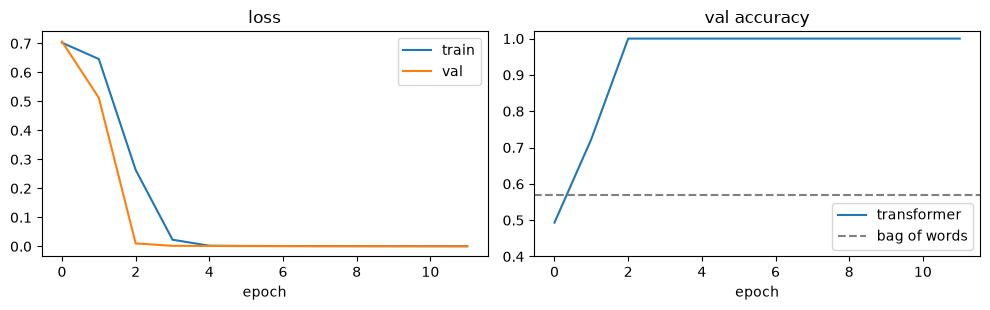

In [9]:
tl, vl, va = zip(*history)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(tl, label="train"); ax[0].plot(vl, label="val"); ax[0].set_title("loss"); ax[0].legend(); ax[0].set_xlabel("epoch")
ax[1].plot(va, label="transformer"); ax[1].axhline(bow_acc, ls="--", c="gray", label="bag of words")
ax[1].set_title("val accuracy"); ax[1].set_ylim(0.4, 1.02); ax[1].legend(); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

### 10. Evaluate, split by negated vs not negated

**What this cell does (plain language):** breaks accuracy down by whether the sentence contains `not`. A good aggregate number can hide a failure on the hard subset, so we always slice by the property we care about.

In [10]:
vloss, vacc = evaluate(model, tok, va_t, va_y)
print(f"overall validation accuracy: {vacc:.3f} (loss {vloss:.3f})")
for name, flag in (("negated", True), ("not negated", False)):
    idx = [i for i, t in enumerate(va_t) if ("not" in t.split()) == flag]
    _, acc = evaluate(model, tok, [va_t[i] for i in idx], va_y[idx])
    print(f"  {name:12s}: n={len(idx):3d} accuracy {acc:.3f}")

overall validation accuracy: 1.000 (loss 0.000)
  negated     : n=122 accuracy 1.000
  not negated : n=178 accuracy 1.000


### 11. Inspect attention from the <cls> position

**What this cell does (plain language):** extracts attention weights of the last layer for one sentence and prints how much the `<cls>` token looks at each word (averaged over heads). This is interpretation, not proof - attention weights are a hint, not a full explanation.

In [11]:
sent = "this movie was not very good today"
ids, mask = tok.batch([sent])
model.eval()
with torch.no_grad():
    logits, attns = model(ids, mask, return_attn=True)
w = attns[-1][0].mean(0)[0]            # last layer, mean over heads, query = <cls> position
words = tok.decode(ids[0].tolist()).split()
for word, weight in zip(words, w.tolist()):
    print(f"{word:8s} {'#' * int(weight * 40)} {weight:.2f}")
print("prediction:", predict(model, tok, sent))

<cls>    # 0.04
this     ### 0.10
movie    ###### 0.17
was      # 0.03
not      #################### 0.50
very     #### 0.11
good      0.02
today    # 0.03
prediction: {'label': 'negative', 'p_positive': 0.0003}


### 12. Inference helper and robustness checks

**What this cell does (plain language):** calls the `predict` helper on hand-written sentences, including negations, unseen words and the empty string. Note the last two rows: the model returns a confident answer even for an empty or unseen-word input, because softmax always sums to 1 and nothing taught it to say 'I don't know'. A deployable classifier needs input checks or an abstain threshold for that.

In [12]:
for s in ["the movie was good", "the movie was not good", "a hotel seemed not bad",
          "this blorptastic show was awesome", ""]:
    print(f"{s!r:40s} -> {predict(model, tok, s)}")

'the movie was good'                     -> {'label': 'positive', 'p_positive': 0.9997}
'the movie was not good'                 -> {'label': 'negative', 'p_positive': 0.0003}
'a hotel seemed not bad'                 -> {'label': 'positive', 'p_positive': 0.9997}
'this blorptastic show was awesome'      -> {'label': 'positive', 'p_positive': 0.9997}
''                                       -> {'label': 'positive', 'p_positive': 0.9997}


## Common bugs

- **No padding mask** — fix: pad tokens influence real tokens and results change with batch composition; pass `pad_mask` and fill scores with `-inf` before softmax.
- **Reading the prediction from the wrong position** — fix: with a `<cls>` design you must pool position 0 (or mean-pool over non-pad tokens), not the last position, which may be padding.
- **Forgetting positional embeddings** — fix: attention alone is order-blind, so `not good` equals `good not`; add position embeddings whenever word order can change the label (in this particular synthetic task it happens not to, see Exercise 3).
- **Scaling scores wrongly** — fix: omitting `1/sqrt(d_k)` saturates the softmax at larger dims and gradients vanish.
- **`d_model` not divisible by heads** — fix: `view(B, T, 3, h, dk)` fails or silently mis-splits; assert divisibility.
- **Leaving dropout on at evaluation** — fix: call `model.eval()`; otherwise accuracy fluctuates between runs.
- **Building the vocabulary on validation data** — fix: fit the tokenizer on training text only (here the corpus is synthetic from one distribution, but real data would leak).
- **Sequences longer than the position table** — fix: `nn.Embedding(max_len, d)` raises an index error; truncate in `encode` as we do.

## Exercises

**Exercise 1.** Change the model to `layers=1` and compare validation accuracy with `layers=2`.

In [13]:
# Your attempt for Exercise 1 here

**Solution 1**

In [14]:
# Solution 1
torch.manual_seed(0); m1 = TransformerClassifier(len(tok), layers=1)
fit(m1, tok, (tr_t, tr_y), (va_t, va_y), epochs=12, verbose=False)
print("1 layer:", evaluate(m1, tok, va_t, va_y)[1])

1 layer: 1.0


**Exercise 2.** Replace `<cls>` pooling with masked mean pooling over non-pad tokens (write a subclass overriding `forward`).

In [15]:
# Your attempt for Exercise 2 here

**Solution 2**

In [16]:
# Solution 2
class MeanPool(TransformerClassifier):
    def forward(self, ids, pad_mask=None, return_attn=False):
        x = self.tok(ids) + self.pos(torch.arange(ids.size(1)))
        for b in self.blocks:
            x = b(x, pad_mask)
        keep = (~pad_mask).unsqueeze(-1).float()
        return self.head((self.ln(x) * keep).sum(1) / keep.sum(1))
torch.manual_seed(0); mp = MeanPool(len(tok))
fit(mp, tok, (tr_t, tr_y), (va_t, va_y), epochs=12, verbose=False)
print("mean-pool acc:", evaluate(mp, tok, va_t, va_y)[1])

mean-pool acc: 1.0


**Exercise 3.** Remove position embeddings (zero and freeze them) and train. Predict whether accuracy drops, then check and explain.

In [17]:
# Your attempt for Exercise 3 here

**Solution 3**

In [18]:
# Solution 3
torch.manual_seed(0); nopos = TransformerClassifier(len(tok))
nn.init.zeros_(nopos.pos.weight); nopos.pos.weight.requires_grad_(False)
fit(nopos, tok, (tr_t, tr_y), (va_t, va_y), epochs=12, verbose=False)
print("no-position acc:", evaluate(nopos, tok, va_t, va_y)[1])
# Accuracy stays high: here the label depends only on WHICH words are present (not + adjective), not on their order,
# so positions add nothing. Positional information matters when order changes the label (e.g. 'dog bites man').

no-position acc: 1.0


**Exercise 4.** Generate a corpus with `p_not=0.0` and re-run the bag-of-words baseline. What accuracy do you expect?

In [19]:
# Your attempt for Exercise 4 here

**Solution 4**

In [20]:
# Solution 4
t0, y0 = make_corpus(1200, seed=1, p_not=0.0)
X0 = bow(t0); l0 = nn.Linear(len(tok), 2); o0 = torch.optim.Adam(l0.parameters(), lr=0.05)
for _ in range(200):
    o0.zero_grad(); nn.functional.cross_entropy(l0(X0), y0).backward(); o0.step()
print("BoW acc without negation:", (l0(X0).argmax(-1) == y0).float().mean().item())  # near 1.0

BoW acc without negation: 1.0


**Exercise 5.** Count how many sentences in the validation set are truncated or contain `<unk>`.

In [21]:
# Your attempt for Exercise 5 here

**Solution 5**

In [22]:
# Solution 5
print("with <unk>:", sum(tok.unk_id in tok.encode(t) for t in va_t), "| truncated:", sum(len(t.split()) + 1 > 16 for t in va_t))

with <unk>: 0 | truncated: 0


**Exercise 6.** Add label smoothing 0.1 to the loss in a custom loop for 3 epochs and print the train loss.

In [23]:
# Your attempt for Exercise 6 here

**Solution 6**

In [24]:
# Solution 6
m = TransformerClassifier(len(tok)); opt = torch.optim.AdamW(m.parameters(), lr=2e-3)
g = torch.Generator().manual_seed(0)
for ep in range(3):
    tot = 0
    for ids, mask, y in make_batches(tok, tr_t, tr_y, 32, True, g):
        opt.zero_grad(); loss = nn.functional.cross_entropy(m(ids, mask), y, label_smoothing=0.1); loss.backward(); opt.step(); tot += loss.item()
    print("epoch", ep, "sum of batch losses", round(tot, 2))

epoch 0 sum of batch losses 20.58


epoch 1 sum of batch losses 19.13


epoch 2 sum of batch losses 15.37
